## ASHRAE Energy Consumption Forecasting

This notebook develops a time-series forecasting model for electricity consumption of Building 1074 using six months of data.

Building 1074 was chosen after looking at the buildings from the building selection tool notebook. It had complete meter-0 data and no zero readings.

Building 1074 is on site 13.

Import the required libraries and load the six months of training data.

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load Building 1074 data directly (or fall back to full train.csv if present)
data_path = Path('../data/building/1074/building_1074.csv')
if not data_path.exists():
    data_path = Path('../data/train.csv')

train = pd.read_csv(data_path)
train['timestamp'] = pd.to_datetime(train['timestamp'])

The data is restricted to building 1074, meter 0, and the first six months of 2016.

In [15]:
train = train[
    (train['building_id'] == 1074)
    & (train['meter'] == 0)
    & train['timestamp'].between('2016-01-01', '2016-06-30 23:00:00')
].reset_index(drop=True)

train.head()
train.shape

(4368, 4)

In [16]:
train.info()
train['timestamp'].dt.hour.unique()
train.describe()

hours = pd.date_range('2016-01-01', '2016-06-30 23:00:00', freq='h')
print('expected readings:', len(hours))
print('actual readings:', len(train))
print('missing timestamps:', len(hours.difference(train['timestamp'])))
print('zero readings:', (train['meter_reading'] == 0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   building_id    4368 non-null   int64         
 1   meter          4368 non-null   int64         
 2   timestamp      4368 non-null   datetime64[us]
 3   meter_reading  4368 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 136.6 KB
expected readings: 4368
actual readings: 4368
missing timestamps: 0
zero readings: 0


plotting the six months of readings to check the pattern.

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(train['timestamp'], train['meter_reading'], linewidth=0.5)
plt.title('Building 1074 meter readings')
plt.xlabel('timestamp')
plt.ylabel('meter reading')
plt.grid(alpha=0.3)
plt.show()

hour-of-day and day-of-week averages.

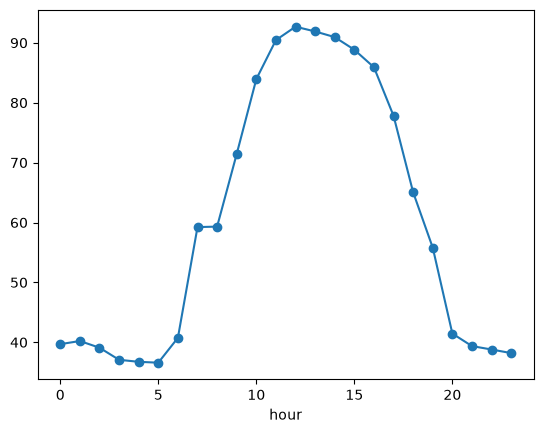

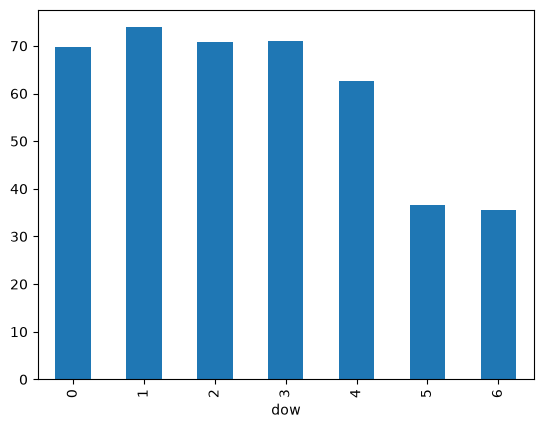

In [17]:
train['hour'] = train['timestamp'].dt.hour
train['dow'] = train['timestamp'].dt.dayofweek
train['month'] = train['timestamp'].dt.month

plt.grid()
train.groupby('hour')['meter_reading'].mean().plot(kind='line', marker='o')
plt.show()

train.groupby('dow')['meter_reading'].mean().plot(kind='bar')
plt.show()

site 13 is Building 1074's site, loading its weather and merging on timestamp.

In [18]:
metadata = pd.read_csv('../data/building_metadata(in).csv')
metadata[metadata['building_id'] == 1074]

weather = pd.read_csv('../data/weather_train.csv')
weather = weather[weather['site_id'] == 13].drop(columns=['site_id'])
weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.isna().sum()

timestamp                0
air_temperature          1
cloud_coverage        4298
dew_temperature          1
precip_depth_1_hr       12
sea_level_pressure     120
wind_direction         217
wind_speed               1
dtype: int64

In [19]:
weather = weather.drop(columns=['cloud_coverage', 'precip_depth_1_hr'])
weather = weather.set_index('timestamp').reindex(
    pd.date_range('2016-01-01', '2016-06-30 23:00:00', freq='h')
).rename_axis('timestamp').reset_index().ffill()

df = train.merge(weather, on='timestamp')
df.isna().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
hour                  0
dow                   0
month                 0
air_temperature       0
dew_temperature       0
sea_level_pressure    0
wind_direction        0
wind_speed            0
dtype: int64

### Feature Engineering

adding previous-day and previous-week readings as lag features.

In [20]:
lookup = df.set_index('timestamp')['meter_reading']

df['lag_24h'] = (df['timestamp'] - pd.Timedelta(hours=24)).map(lookup)
df['lag_168h'] = (df['timestamp'] - pd.Timedelta(hours=168)).map(lookup)

df[['timestamp', 'meter_reading', 'lag_24h', 'lag_168h']].head(10)

,timestamp,meter_reading,lag_24h,lag_168h
0,2016-01-01 00:00:00,39.249,NaN,NaN
1,2016-01-01 01:00:00,39.249,NaN,NaN
2,2016-01-01 02:00:00,37.862,NaN,NaN
3,2016-01-01 03:00:00,35.834,NaN,NaN
4,2016-01-01 04:00:00,35.495,NaN,NaN
5,2016-01-01 05:00:00,35.477,NaN,NaN
6,2016-01-01 06:00:00,38.050,NaN,NaN
7,2016-01-01 07:00:00,43.351,NaN,NaN
8,2016-01-01 08:00:00,43.266,NaN,NaN
9,2016-01-01 09:00:00,39.869,NaN,NaN


Splitting the data chronologically - first 80% for training, last 20% for testing.

In [21]:
df_model = df.dropna(subset=['lag_24h', 'lag_168h']).reset_index(drop=True)
print('before:', df.shape, ' after:', df_model.shape)

a = int(len(df_model) * 0.8)
train_df = df_model.iloc[:a]
test_df = df_model.iloc[a:]

features = ['hour', 'dow', 'month', 'lag_24h', 'lag_168h']
target = 'meter_reading'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

before: (4368, 14)  after: (4200, 14)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Saving the trained model so it can be loaded later by the Flask dashboard.

In [14]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/building_1074_six_months_model.pkl')
print('Model saved to ../models/building_1074_six_months_model.pkl')

predictions = model.predict(X_test)
predictions[:10]

Model saved to ../models/building_1074_six_months_model.pkl


array([35.621437, 37.150826, 35.961113, 34.02157 , 33.197044, 33.48827 ,
       36.31331 , 62.805264, 53.7463  , 62.19798 ], dtype=float32)

## Model Evaluation

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = (mean_squared_error(y_test, predictions))**0.5
mae = mean_absolute_error(y_test, predictions)

baseline_preds = test_df['lag_168h']
baseline_rmse = (mean_squared_error(y_test, baseline_preds))**0.5
baseline_mae = mean_absolute_error(y_test, baseline_preds)

print('baseline RMSE:', baseline_rmse, ' baseline MAE:', baseline_mae)
print('xgboost RMSE:', rmse, ' xgboost MAE:', mae)

baseline RMSE: 10.171403026377433  baseline MAE: 5.910753571428571
xgboost RMSE: 10.148919256508773  xgboost MAE: 6.08584958472479


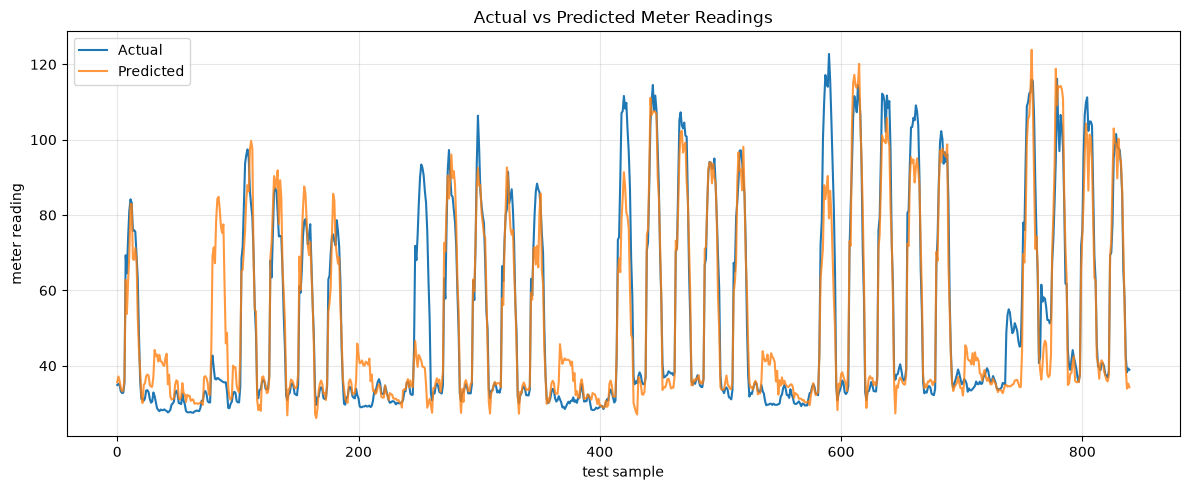

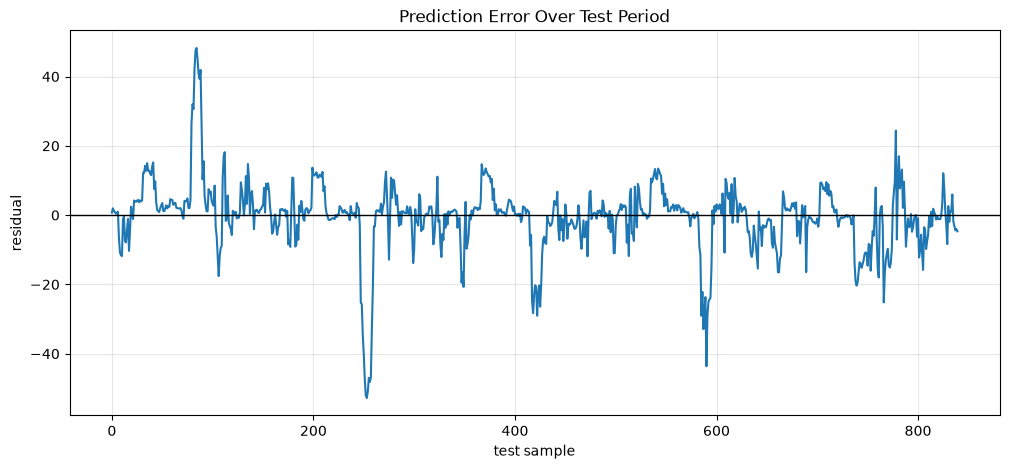

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.to_numpy(), label='Actual', linewidth=1.5)
plt.plot(predictions, label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('test sample')
plt.ylabel('meter reading')
plt.title('Actual vs Predicted Meter Readings')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

residuals = predictions - y_test.to_numpy()
plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('test sample')
plt.ylabel('residual')
plt.title('Prediction Error Over Test Period')
plt.grid(alpha=0.3)
plt.show()

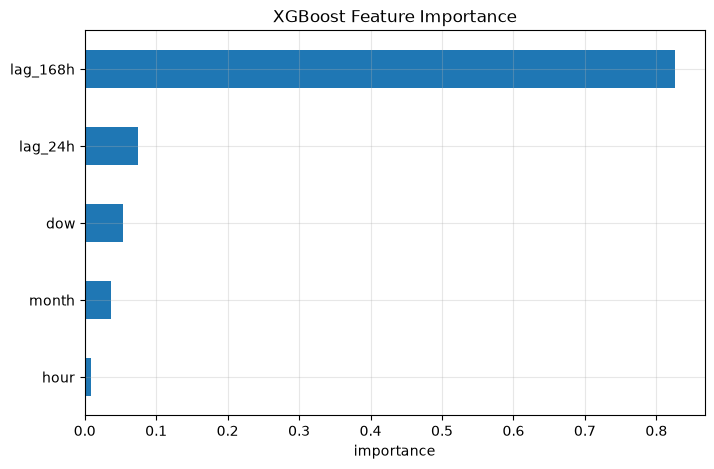

In [24]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.xlabel('importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

The saved model uses `hour`, `dow`, `month`, `lag_24h`, and `lag_168h`. These features can be created in the Flask dashboard for next month's predictions.